# Experiment 1.2: Real Per-View Attributes (Ablation)

This notebook is a modified copy of `04_train_s1_with_tessa_baseline.ipynb`, created to run **Phase 1.2** from `TODO_next_experiments.md` without touching the working baseline notebook.

## What this tests

The baseline notebook feeds Tessa's `ConditionalUNet` an all-zero `attrs` tensor for every Sentinel-1 view. Tessa's `AttrAwareSpatialPool` is specifically designed to use per-view metadata (cloud cover, sun/view angles, acquisition age) to weight which views the model trusts more when fusing them -- an all-zero input defeats that mechanism entirely, since every view looks identically "unremarkable" to the attention weighting regardless of how much time has passed since the LiDAR survey or which orbit direction it came from.

This notebook replaces the zero-filled attrs with real per-view metadata already sitting in `s1_patches_tuk_michel_provided`'s `attrs.json` (acquisition_date, orbit_direction, relative_orbit_number). Everything else -- data, split seed, channel repetition, training loop, sampler, metrics -- is identical to notebook 04, so any difference in ZNCC/RMSE/JSD is attributable specifically to giving the fusion mechanism real signal to work with.

This notebook does not execute automatically. Run cells top to bottom on the GPU workstation.

## GPU configuration

This notebook requires a CUDA-enabled PyTorch installation.

In [1]:
import os
import sys
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), 'CUDA is required. Run this notebook on the GPU environment.'
DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True
print('GPU:', torch.cuda.get_device_name(0))

GPU: NVIDIA GeForce RTX 4070 Ti SUPER


## Paths and training configuration

Same paths as notebook 04's final run. `EXPERIMENT_TAG = 'realattrs'` isolates every output of this notebook (checkpoint, metrics JSON, plots) from notebook 04's baseline and from other experiments, so nothing gets overwritten and you can diff them directly afterward.

In [2]:
WORKING_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche')
TESSA_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche/tessa_baseline')
REGION = 'tuk'
EXPERIMENT_TAG = 'realattrs'
S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_tuk_michel_provided'
LIDAR_DIR = WORKING_REPO / 'input_data' / 'lidar_patches_tuk_tessa'
CHECKPOINT_DIR = WORKING_REPO / 'checkpoints'
OUTPUT_DIR = WORKING_REPO / 's1_training_outputs'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_NAME = f's1_{REGION}_{EXPERIMENT_TAG}_unet_best.pth'
METRICS_FILENAME = f's1_{EXPERIMENT_TAG}_validation_metrics.json'
CONTEXT_K = 3
TARGET_HW = (256, 256)
BATCH_SIZE = 8
EPOCHS = 100
TIMESTEPS = 1000
LEARNING_RATE = 1e-4
VAL_FRACTION = 0.15
SEED = 42
NOISE_SCHEDULE = 'linear'
ATTENTION_VARIANT = 'default'
LIDAR_SURVEY_DATE = __import__('datetime').date(2024, 4, 16)  # Tuk LiDAR acquisition date

## Import Tessa's baseline implementation

The working tree intentionally does not contain Tessa's model and metrics modules, so imports use the cloned baseline path explicitly.

In [3]:
sys.path.insert(0, str(TESSA_REPO))
from src.model.unet import ConditionalUNet
from src.diffusion.scheduler import LinearDiffusionScheduler, CosineDiffusionScheduler
from src.diffusion.sampling import p_sample_loop_ddpm, p_sample_loop_ddim, p_sample_loop_plms
from src.utils.recon_metrics import rmse, bias, sigma_error, normal_angle_error, average_jsd_multiscale, log_psd_rmse, zncc

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

## Sentinel-1/LiDAR dataset adapter -- real attrs version

`build_real_attrs` reads each view's `attrs.json` entry and encodes: acquisition age relative to the LiDAR survey date (normalized by 30 days), orbit direction (1.0 = ascending, 0.0 = descending), and relative orbit number (normalized by 175, the Sentinel-1 orbit cycle length). The remaining 5 of 8 attribute slots stay zero -- Sentinel-1 products don't carry a direct analog to Sentinel-2's cloud-cover/sun-angle fields, so there's nothing meaningful to put there yet. Channel repetition (`[VV, VH, VV, VH]`) is left unchanged from the baseline, since this experiment isolates the attrs variable only.

In [4]:
def build_real_attrs(s1_path, times, context_k):
    attrs_path = s1_path / 'attrs.json'
    attrs_list = json.load(open(attrs_path)) if attrs_path.exists() else []
    vecs = []
    for time_path in times:
        idx = int(time_path.stem[1:])  # 't0' -> 0
        a = attrs_list[idx] if idx < len(attrs_list) else {}
        if a.get('acquisition_date'):
            import datetime as dt
            acq_date = dt.date.fromisoformat(a['acquisition_date'])
            age_days = (acq_date - LIDAR_SURVEY_DATE).days
            age_norm = age_days / 30.0
        else:
            age_norm = 0.0
        orbit_dir = 1.0 if a.get('orbit_direction') == 'ASCENDING' else 0.0
        rel_orbit = (a.get('relative_orbit_number') or 0) / 175.0
        vecs.append([age_norm, orbit_dir, rel_orbit, 0.0, 0.0, 0.0, 0.0, 0.0])
    return torch.tensor(vecs, dtype=torch.float32).flatten()


class LidarS1Dataset(Dataset):
    def __init__(self, s1_dir, lidar_dir, patch_ids, context_k=3, target_hw=(256, 256), train=False):
        self.s1_dir = Path(s1_dir)
        self.lidar_dir = Path(lidar_dir)
        self.patch_ids = list(patch_ids)
        self.context_k = context_k
        self.target_hw = target_hw
        self.train = train

    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, index):
        patch_id = self.patch_ids[index]
        lidar_path = self.lidar_dir / f'lidar_patch_{patch_id}.tif'
        s1_path = self.s1_dir / f's1_patch_{patch_id}'
        with rasterio.open(lidar_path) as src:
            raw = src.read().astype(np.float32)
        target = raw[0]
        mask = (raw[1] > 0.5) if raw.shape[0] > 1 else np.isfinite(target)
        target = np.nan_to_num(target, nan=0.0, posinf=0.0, neginf=0.0)
        valid_count = max(1, int(mask.sum()))
        patch_mean = float(target[mask].sum() / valid_count)
        target = (target - patch_mean) * mask

        times = sorted(s1_path.glob('t*.tif'))[:self.context_k]
        if len(times) < self.context_k:
            raise RuntimeError(f'{s1_path} has fewer than {self.context_k} Sentinel-1 times')
        views = []
        for time_path in times:
            with rasterio.open(time_path) as src:
                sar = src.read()[:2].astype(np.float32)
            sar = np.nan_to_num(sar, nan=0.0, posinf=0.0, neginf=0.0)
            sar = np.maximum(sar, 1e-12)
            sar = 10.0 * np.log10(sar)
            sar_tensor = torch.from_numpy(sar).unsqueeze(0)
            sar_tensor = F.interpolate(sar_tensor, size=self.target_hw, mode='bilinear', align_corners=False).squeeze(0)
            sar_tensor = sar_tensor.repeat(2, 1, 1)
            views.append(sar_tensor)
        condition = torch.cat(views, dim=0)
        attrs = build_real_attrs(s1_path, times, self.context_k)
        return {'lidar': torch.from_numpy(target).unsqueeze(0).float(), 'mask': torch.from_numpy(mask), 's1': condition.float(), 'attrs': attrs, 'patch_mean': torch.tensor(patch_mean), 'patch_id': patch_id}

## Pair patches and create a reproducible split

Same split logic and `SEED` as notebook 04's baseline -- with matching `S1_DIR`/`LIDAR_DIR`, this reproduces the identical train/val patch split, so this run is comparable to the baseline.

In [5]:
lidar_ids = {p.stem.split('_')[-1] for p in LIDAR_DIR.glob('lidar_patch_*.tif')}
s1_ids = {p.name.split('_')[-1] for p in S1_DIR.glob('s1_patch_*') if p.is_dir()}
paired_ids = sorted(lidar_ids & s1_ids)
assert paired_ids, 'No paired Sentinel-1/LiDAR patches found.'
random.Random(SEED).shuffle(paired_ids)
n_val = max(1, int(len(paired_ids) * VAL_FRACTION))
val_ids, train_ids = paired_ids[:n_val], paired_ids[n_val:]
print(f'Paired: {len(paired_ids)} | train: {len(train_ids)} | validation: {len(val_ids)}')
train_dataset = LidarS1Dataset(S1_DIR, LIDAR_DIR, train_ids, CONTEXT_K, TARGET_HW, train=True)
val_dataset = LidarS1Dataset(S1_DIR, LIDAR_DIR, val_ids, CONTEXT_K, TARGET_HW, train=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Paired: 1676 | train: 1425 | validation: 251


## Initialize Tessa's ConditionalUNet and scheduler

Same architecture shape as the notebook-04 baseline (`cond_channels=4*CONTEXT_K`, `attr_dim=8*CONTEXT_K`, default `cond_channels_per_view=4`) -- this experiment only changes what data feeds into the dataset, not the model shape, so it starts from freshly initialized weights but is architecturally identical to the baseline.

In [6]:
model = ConditionalUNet(in_channels=1, cond_channels=4 * CONTEXT_K, attr_dim=8 * CONTEXT_K, base_channels=128, embed_dim=256, unet_depth=4, attention_variant=ATTENTION_VARIANT, cond_k=CONTEXT_K).to(DEVICE)
scheduler = (LinearDiffusionScheduler(TIMESTEPS, device=DEVICE) if NOISE_SCHEDULE == 'linear' else CosineDiffusionScheduler(TIMESTEPS, device=DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 104625307


## Training loop

Identical objective and loop to notebook 04: sample a diffusion timestep, add forward noise to the demeaned LiDAR target, predict the clean target, optimize masked MSE. Only the checkpoint filename differs (tagged, so it never overwrites the baseline or any other experiment's checkpoint). `num_workers=0` is used deliberately -- notebook 04 was fixed to this after a CUDA-context/`fork()` DataLoader crash, so this copy starts from that already-fixed version.

In [ ]:
def masked_mse(prediction, target, mask):
    valid = mask.bool().unsqueeze(1)
    error = (prediction - target) ** 2
    return error[valid].mean()

history = {'train_loss': [], 'val_loss': []}
best_val = float('inf')
for epoch in range(EPOCHS):
    model.train()
    train_total = 0.0
    for batch in train_loader:
        target = batch['lidar'].to(DEVICE, non_blocking=True)
        condition = batch['s1'].to(DEVICE, non_blocking=True)
        attrs = batch['attrs'].to(DEVICE, non_blocking=True)
        mask = batch['mask'].to(DEVICE, non_blocking=True)
        timestep = torch.randint(0, TIMESTEPS, (target.size(0),), device=DEVICE)
        noisy = scheduler.q_sample(target, timestep)
        prediction = model(noisy, condition, attrs, timestep)
        loss = masked_mse(prediction, target, mask)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        train_total += loss.item()
    model.eval()
    val_total = 0.0
    with torch.no_grad():
        for batch in val_loader:
            target = batch['lidar'].to(DEVICE, non_blocking=True)
            condition = batch['s1'].to(DEVICE, non_blocking=True)
            attrs = batch['attrs'].to(DEVICE, non_blocking=True)
            mask = batch['mask'].to(DEVICE, non_blocking=True)
            timestep = torch.randint(0, TIMESTEPS, (target.size(0),), device=DEVICE)
            prediction = model(scheduler.q_sample(target, timestep), condition, attrs, timestep)
            val_total += masked_mse(prediction, target, mask).item()
    train_loss = train_total / max(1, len(train_loader))
    val_loss = val_total / max(1, len(val_loader))
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    print(f'Epoch {epoch + 1:03d}/{EPOCHS}: train={train_loss:.6f} val={val_loss:.6f}')
    if val_loss < best_val:
        best_val = val_loss
        torch.save({'model_state_dict': model.state_dict(), 'config': {'context_k': CONTEXT_K, 'timesteps': TIMESTEPS, 'noise_schedule': NOISE_SCHEDULE, 'region': REGION, 'experiment_tag': EXPERIMENT_TAG}, 'epoch': epoch + 1, 'val_loss': val_loss}, CHECKPOINT_DIR / CHECKPOINT_NAME)

## Evaluate with Tessa's reconstruction metrics

Loads this experiment's own checkpoint (not the baseline's). Uses DDIM for deterministic comparison, same metric family as notebook 04.

In [7]:
best_path = CHECKPOINT_DIR / CHECKPOINT_NAME
checkpoint = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
sampler = p_sample_loop_ddim
metric_rows = []
example_patches = []
N_EXAMPLES = 6
with torch.no_grad():
    for batch in val_loader:
        target = batch['lidar'].to(DEVICE)
        condition = batch['s1'].to(DEVICE)
        attrs = batch['attrs'].to(DEVICE)
        mask = batch['mask'].to(DEVICE).bool()
        prediction = sampler(model, scheduler, target.shape, condition, attrs, DEVICE)
        means = batch['patch_mean'].to(DEVICE).view(-1, 1, 1, 1)
        gt_absolute = target + means
        pred_absolute = prediction + means
        for i, patch_id in enumerate(batch['patch_id']):
            gt_i, pred_i, mask_i = gt_absolute[i], pred_absolute[i], mask[i]
            gt_valid = gt_i.squeeze()[mask_i].cpu().numpy()
            pred_valid = pred_i.squeeze()[mask_i].cpu().numpy()
            row = {
                'patch_id': patch_id,
                'rmse_m': float(rmse(gt_i, pred_i, mask_i).item()),
                'bias_m': float(bias(gt_i, pred_i, mask_i).item()),
                'sigma_error_pct': float(sigma_error(gt_i, pred_i, mask_i).item()),
                'normal_angle_error_deg': float(normal_angle_error(gt_i, pred_i, mask_i, pixel_size=1.0, degrees=True).item()),
                'jsd': float(average_jsd_multiscale(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
                'psd_rmse': float(log_psd_rmse(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
                'zncc': float(zncc(gt_i, pred_i, mask_i).item()),
                'gt_std_val': float(gt_valid.std()) if gt_valid.size > 0 else float('nan'),
                'pred_std_val': float(pred_valid.std()) if pred_valid.size > 0 else float('nan'),
            }
            metric_rows.append(row)
            if len(example_patches) < N_EXAMPLES:
                example_patches.append({
                    'patch_id': patch_id,
                    'gt': gt_i.squeeze().cpu().numpy(),
                    'pred': pred_i.squeeze().cpu().numpy(),
                    'mask': mask_i.squeeze().cpu().numpy(),
                    's1_condition': condition[i].cpu().numpy(),
                })
metrics_path = OUTPUT_DIR / METRICS_FILENAME
with metrics_path.open('w') as handle:
    json.dump(metric_rows, handle, indent=2)
print('Saved:', metrics_path)
print('Mean metrics:', {key: float(np.nanmean([row[key] for row in metric_rows])) for key in metric_rows[0] if key != 'patch_id'})

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_realattrs_validation_metrics.json
Mean metrics: {'rmse_m': 0.19540897569808352, 'bias_m': -0.007474505793768449, 'sigma_error_pct': 29.205678184490754, 'normal_angle_error_deg': 1.9108183847005624, 'jsd': 0.1286713858635955, 'psd_rmse': 1.7737406024419928, 'zncc': 0.16508227841584458, 'gt_std_val': 0.16917210750548964, 'pred_std_val': 0.12746195958192605}


Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_realattrs_metric_violin_plots.png


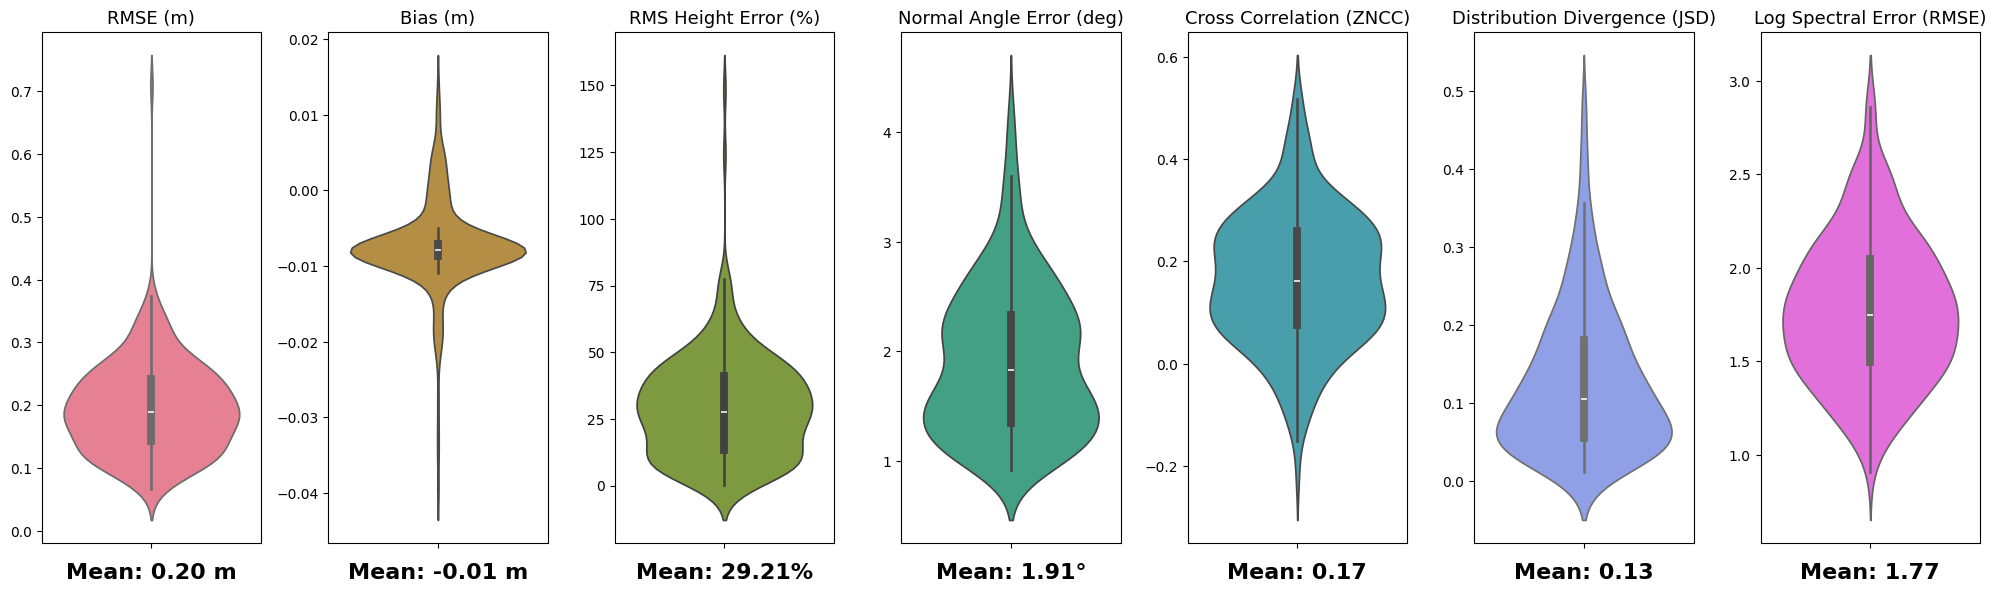

In [8]:
import pandas as pd
import seaborn as sns

df_val = pd.DataFrame(metric_rows)

metric_column_names = ['rmse_m', 'bias_m', 'sigma_error_pct', 'normal_angle_error_deg', 'zncc', 'jsd', 'psd_rmse']
metric_column_dict = {
    'rmse_m': 'RMSE (m)',
    'bias_m': 'Bias (m)',
    'sigma_error_pct': 'RMS Height Error (%)',
    'normal_angle_error_deg': 'Normal Angle Error (deg)',
    'zncc': 'Cross Correlation (ZNCC)',
    'jsd': 'Distribution Divergence (JSD)',
    'psd_rmse': 'Log Spectral Error (RMSE)',
}
metric_units_dict = {
    'rmse_m': ' m', 'bias_m': ' m', 'sigma_error_pct': '%', 'normal_angle_error_deg': '°',
    'zncc': '', 'jsd': '', 'psd_rmse': '',
}

fig, axes = plt.subplots(1, len(metric_column_names), figsize=(20, 6))
axes = axes.flatten()
colors = sns.color_palette('husl', len(metric_column_names))
for i, metric in enumerate(metric_column_names):
    sns.violinplot(y=df_val[metric], ax=axes[i], color=colors[i])
    axes[i].set_title(metric_column_dict[metric], fontsize=13)
    axes[i].set_ylabel('')
    mean_value = df_val[metric].mean()
    axes[i].annotate(f'Mean: {mean_value:.2f}{metric_units_dict[metric]}', xy=(0.5, -0.07), xycoords='axes fraction', ha='center', fontsize=16, color='black', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f's1_{EXPERIMENT_TAG}_metric_violin_plots.png', dpi=150, bbox_inches='tight')
print('Saved:', OUTPUT_DIR / f's1_{EXPERIMENT_TAG}_metric_violin_plots.png')
plt.show()


Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_realattrs_gt_pred_std_scatter.png


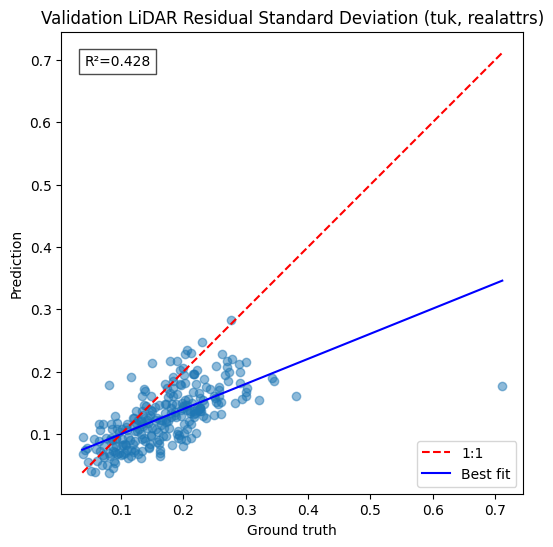

In [9]:
df_val = pd.DataFrame(metric_rows)

x = df_val['gt_std_val']
y = df_val['pred_std_val']

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5)

mn, mx = np.nanmin([x, y]), np.nanmax([x, y])
plt.plot([mn, mx], [mn, mx], 'r--', label='1:1')

mask = ~np.isnan(x) & ~np.isnan(y)
z = np.polyfit(x[mask], y[mask], 1)
p = np.poly1d(z)
xs = np.array([mn, mx])
plt.plot(xs, p(xs), 'b-', label='Best fit')

r2 = np.corrcoef(x[mask], y[mask])[0, 1] ** 2
plt.text(0.05, 0.95, f'R²={r2:.3f}', transform=plt.gca().transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))

plt.xlabel('Ground truth')
plt.ylabel('Prediction')
plt.title(f'Validation LiDAR Residual Standard Deviation ({REGION}, {EXPERIMENT_TAG})')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.savefig(OUTPUT_DIR / f's1_{EXPERIMENT_TAG}_gt_pred_std_scatter.png', dpi=150, bbox_inches='tight')
print('Saved:', OUTPUT_DIR / f's1_{EXPERIMENT_TAG}_gt_pred_std_scatter.png')
plt.show()


## Comparison protocol

Compare `s1_realattrs_validation_metrics.json` (this notebook) against `s1_validation_metrics.json` (notebook 04's baseline) on the same patch split. Focus on `zncc` and `jsd` first -- if this experiment meaningfully improves ZNCC over the baseline's 0.166-0.183, that identifies this as (part of) the real bottleneck. If it barely moves, this factor alone doesn't explain the Sentinel-1 vs Sentinel-2 gap -- see `TODO_next_experiments.md` for the next item in Phase 1, or Phase 2 if all of Phase 1 is inconclusive.